In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from tqdm import tqdm

sys.path.append("..")

os.environ["CUDA_VISIBLE_DEVICES"] = "2"

import torch

In [3]:
def compute_pearson_correlation(x, y):
    # shape of [c, ...]
    n_channels = x.shape[0]
    x = x.view(n_channels, -1)
    y = y.view(n_channels, -1)
    x = x - torch.mean(x, dim=1, keepdim=True)
    y = y - torch.mean(y, dim=1, keepdim=True)
    cov = torch.sum(x * y, dim=1)
    std_x = torch.linalg.norm(x, dim=1)
    std_y = torch.linalg.norm(y, dim=1)
    return torch.mean(cov / (std_x * std_y))

resolution = [12, 32, 43, 12]
x1 = torch.rand(resolution)
# x2 = torch.rand(resolution)
x2 = x1 + 5

compute_pearson_correlation(x1, x2)

tensor(1.0000)

In [4]:
CKP = "outputs/20250207_095246/"
device = "cuda"

In [5]:
import yaml
from omegaconf import OmegaConf

from utils import load_model_and_config
from models import get_model

from dataset.cyclone import CycloneDataset

cfg = OmegaConf.create(yaml.safe_load(open(f"{CKP}/config.yaml", "r")))

data = CycloneDataset(
    active_keys=cfg.dataset.active_keys,
    split="val",
    random_seed=cfg.seed,
    normalization=cfg.dataset.normalization,
    normalization_scope=cfg.dataset.normalization_scope,
    spatial_ifft=cfg.dataset.spatial_ifft,
    in_memory=False,
    bundle_seq_length=cfg.model.bundle_seq_length,
    trajectories=["cyclone4_2_2.h5"],
)

print(f"Val: {len(data)}")

Val: 165


In [6]:
model = get_model(cfg, dataset=data)

model, _, _ = load_model_and_config(f"{CKP}/best.pth", model, device)

model = model.to(device)
model.eval()

Parameters: 122.6M
Loading model outputs/20250207_095246//best.pth (stopped at epoch 500) with loss 0.193302


SwinUnet(
  (cond_embed): ContinuousConditionEmbed(
    (mlp): Sequential(
      (0): Linear(in_features=32, out_features=128, bias=True)
      (1): SiLU()
    )
  )
  (patch_embed): PatchEmbed(
    (patch): MLP(
      (mlp): Sequential(
        (0): Linear(in_features=2048, out_features=4096, bias=False)
        (1): Identity()
        (2): GELU(approximate='none')
        (3): Linear(in_features=4096, out_features=256, bias=False)
        (4): Identity()
      )
    )
    (norm): Identity()
  )
  (down_blocks): ModuleList(
    (0): SwinBlockDown(
      (pos_embed): PositionalEmbedding()
      (swin_att): ModulatedSwinLayer(
        (blocks): ModuleList(
          (0-3): 4 x SwinTransformerBlock(
            (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
            (attn): WindowAttention(
              (cpb_mlp): MLP(
                (mlp): Sequential(
                  (0): Linear(in_features=5, out_features=512, bias=True)
                  (1): Identity()
        

In [7]:
gt_correlations = []
model_correlations_prev = []
model_correlations_gt = []
timesteps = data.get_timesteps(torch.tensor([0], dtype=torch.long))
with torch.no_grad():
   for idx in tqdm(range(len(data) - 1), total=len(data)-1):
      sample = data[idx]
      x_in = sample.x
      x_in = x_in.to(device).unsqueeze(0)
      itg = sample.itg.unsqueeze(0).to(device)
      ts = timesteps[:, idx].to(device)
      # ts = sample.timestep.unsqueeze(0).to(device)
      pred = model(x_in, timestep=ts, itg=itg)
      # calculate correlations
      correlation_gt = compute_pearson_correlation(sample.x, sample.y)
      gt_correlations.append(correlation_gt.cpu())
      correlation_model_gt = compute_pearson_correlation(sample.y.to(device), pred.unsqueeze(0))
      model_correlations_gt.append(correlation_model_gt.cpu())
      correlation_model_prev = compute_pearson_correlation(sample.x.to(device), pred.unsqueeze(0))
      model_correlations_prev.append(correlation_model_prev.cpu())

100%|██████████| 164/164 [06:17<00:00,  2.30s/it]


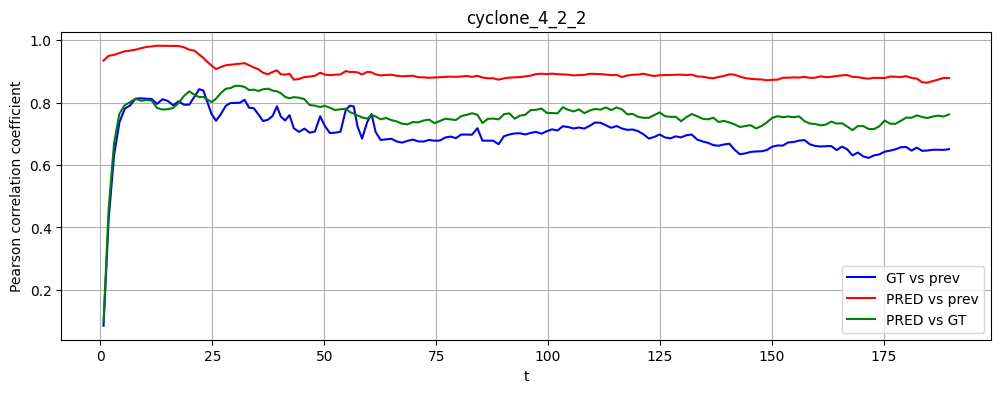

In [8]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(timesteps[0, :-1], gt_correlations, label="GT vs prev", c="b")
ax.plot(timesteps[0, :-1], model_correlations_gt, label="PRED vs prev", c="r")
ax.plot(timesteps[0, :-1], model_correlations_prev, label="PRED vs GT", c="g")

ax.legend()
ax.set_xlabel("t")
ax.set_ylabel("Pearson correlation coefficient")
ax.set_title("cyclone_4_2_2")
plt.grid()